In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('netflix_titles.csv',encoding = "latin1")

In [4]:
print(df.isnull().sum())

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
df.fillna({'country':'Unknown','director':'Unknown','rating':'unknown','date_added':'Unknown'},inplace=True)
df['duration'] = df['duration'].astype(str).str.replace('min','', regex=True).str.replace('Season','', regex=True).str.replace('s','', regex=True)
df['duration'] = pd.to_numeric(df['duration'],errors='coerce')

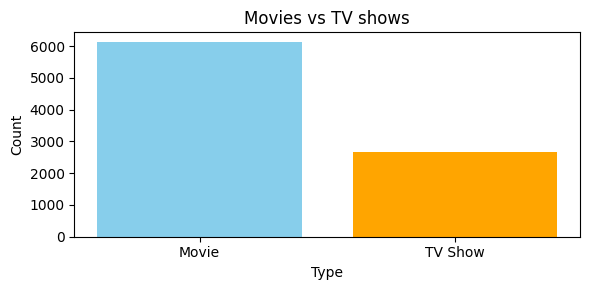

In [6]:
count_types = df['type'].value_counts()
plt.figure(figsize=(6,3))
plt.bar(count_types.index,count_types.values,color=['skyblue','orange'])
plt.title("Movies vs TV shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

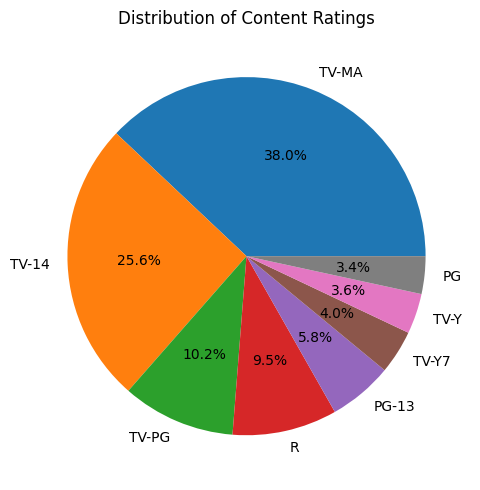

In [7]:
rating_count = df['rating'].value_counts().head(8)
plt.figure(figsize=(8,5))
plt.pie(rating_count,labels=rating_count.index,autopct="%1.1f%%")
plt.title("Distribution of Content Ratings")
plt.tight_layout()
plt.show()

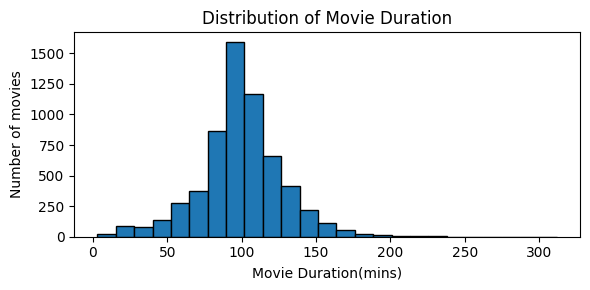

In [8]:
movie_df = df[df['type'] == "Movie"]
plt.figure(figsize=(6,3))
plt.hist(movie_df['duration'],bins=25,edgecolor='black')
plt.title("Distribution of Movie Duration")
plt.xlabel("Movie Duration(mins)")
plt.ylabel("Number of movies")
plt.tight_layout()

plt.show()

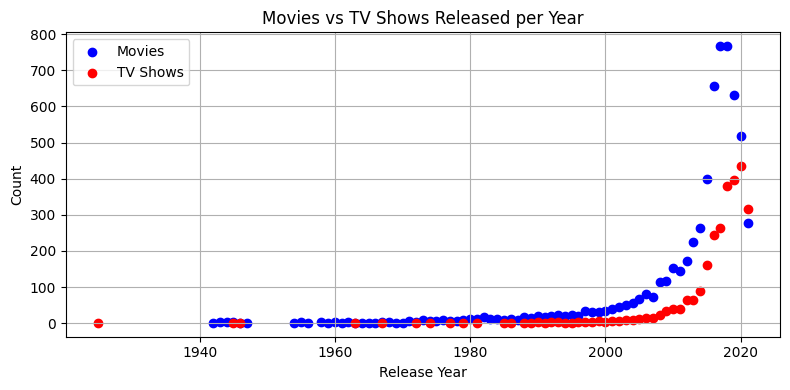

In [9]:
shows_per_year = df[df['type'] =='TV Show']['release_year'].value_counts().sort_index()
movies_per_year = df[df['type'] =='Movie']['release_year'].value_counts().sort_index()
plt.figure(figsize=(8,4))
plt.scatter(movies_per_year.index,movies_per_year.values,color='blue',label='Movies')
plt.scatter(shows_per_year.index,shows_per_year.values,color = 'red',label ='TV Shows')
plt.title("Movies vs TV Shows Released per Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

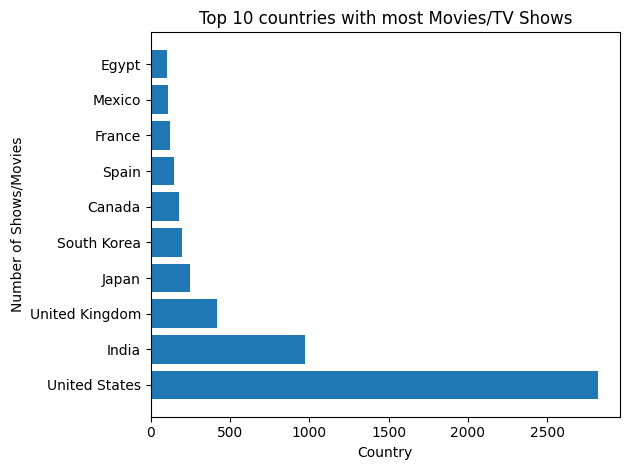

In [10]:
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
# plt.figure(figsize=(6,3))
plt.barh(top_countries.index,top_countries.values)
plt.title("Top 10 countries with most Movies/TV Shows")
plt.xlabel("Country")
plt.ylabel("Number of Shows/Movies")
plt.tight_layout()
plt.show()


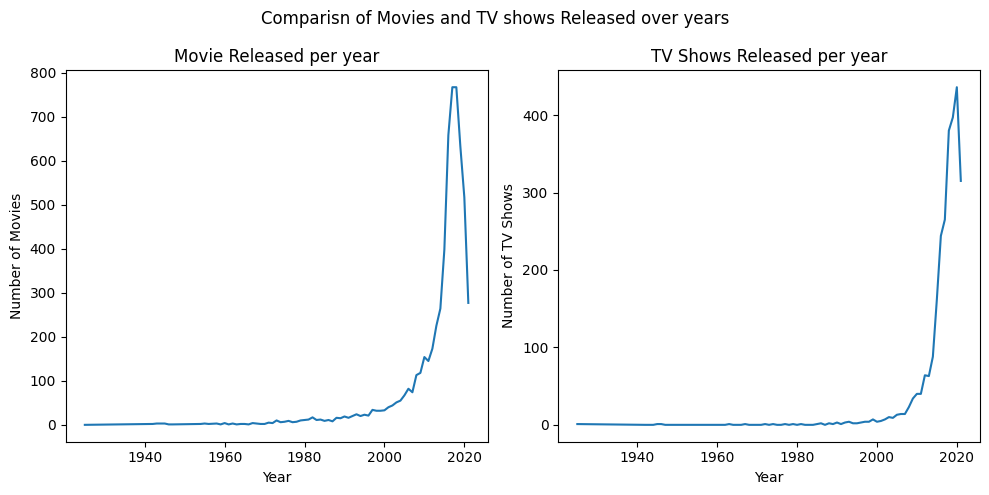

In [11]:
content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(content_by_year.index,content_by_year['Movie'])
ax[0].set_title("Movie Released per year")
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Number of Movies')

ax[1].plot(content_by_year.index,content_by_year['TV Show'])
ax[1].set_title("TV Shows Released per year")
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Number of TV Shows')

fig.suptitle("Comparisn of Movies and TV shows Released over years")
plt.tight_layout()
plt.show()
